In [2]:
import pandas as pd
from catboost import CatBoostRegressor

In [3]:
df = pd.read_csv('refined_df.csv', index_col=0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6674 entries, row_00000 to row_08522
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_code         6674 non-null   object 
 1   product_weight_kg    6674 non-null   float64
 2   fat_content          6674 non-null   object 
 3   shelf_visibility     6674 non-null   float64
 4   product_category     6674 non-null   object 
 5   product_price        6674 non-null   float64
 6   store_code           6674 non-null   object 
 7   store_age_years      6674 non-null   int64  
 8   store_size           6674 non-null   object 
 9   store_location_tier  6674 non-null   object 
 10  store_format         6674 non-null   object 
 11  total_sales          6674 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 677.8+ KB


In [5]:
test_df = pd.read_csv('refined_test_df.csv', index_col=0)

FEATURE ENGINEERING

In [6]:
df_v2 = df.copy()
test_df_v2 = test_df.copy()

In [7]:
df_v2['category_average_price/store'] = df_v2.groupby(['product_category', 'store_code'])['product_price'].transform('mean')
df_v2['relative_category_price'] = df_v2['product_price'] / df_v2['category_average_price/store']

test_df_v2['category_average_price/store'] = test_df_v2.groupby(['product_category', 'store_code'])['product_price'].transform('mean')
test_df_v2['relative_category_price'] = test_df_v2['product_price'] / test_df_v2['category_average_price/store']

In [8]:
df_v2['product_average_price/store'] = df_v2.groupby(['product_code'])['product_price'].transform('mean')
df_v2['relative_product_price'] = df_v2['product_price'] / df_v2['product_average_price/store']

test_df_v2['product_average_price/store'] = test_df_v2.groupby(['product_code'])['product_price'].transform('mean')
test_df_v2['relative_product_price'] = test_df_v2['product_price'] / test_df_v2['product_average_price/store']

In [9]:
df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6674 entries, row_00000 to row_08522
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   product_code                  6674 non-null   object 
 1   product_weight_kg             6674 non-null   float64
 2   fat_content                   6674 non-null   object 
 3   shelf_visibility              6674 non-null   float64
 4   product_category              6674 non-null   object 
 5   product_price                 6674 non-null   float64
 6   store_code                    6674 non-null   object 
 7   store_age_years               6674 non-null   int64  
 8   store_size                    6674 non-null   object 
 9   store_location_tier           6674 non-null   object 
 10  store_format                  6674 non-null   object 
 11  total_sales                   6674 non-null   float64
 12  category_average_price/store  6674 non-null   float64


In [10]:
df_v2.head(10)

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,category_average_price/store,relative_category_price,product_average_price/store,relative_product_price
id,,,,,,,,,,,,,,,,
row_00000,PRD-PRFP9S,14.252000,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,136.310822,0.596945,78.300000,1.039208
row_00001,PRD-PXXK71,7.698000,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,121.862821,0.345060,44.572000,0.943417
row_00002,PRD-V5MOIJ,14.264000,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,138.346667,0.298887,41.751667,0.990380
row_00003,PRD-UN5Z3J,12.899667,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,108.516471,1.606669,176.570000,0.987427
row_00004,PRD-6RDQYB,10.338000,Regular,0.0120,Meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,149.834359,1.355230,196.810000,1.031757
row_00005,PRD-E6VA05,9.222000,Low Fat,0.0405,Soft Drinks,31.69,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,842.75,117.161053,0.270482,32.050000,0.988768
row_00006,PRD-MHLD93,6.256800,Low Fat,0.1239,Canned,212.23,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,4512.70,132.703019,1.599285,209.551667,1.012781
row_00007,PRD-EF6Y39,10.210000,Regular,0.0133,Snack Foods,142.70,STORE-HL7,23,Medium,Tier_3,Superstore,2373.55,143.865051,0.991902,141.628333,1.007567
row_00008,PRD-IAZMTU,14.054000,Low Fat,0.0233,Baking Goods,102.71,STORE-HL7,23,Medium,Tier_3,Superstore,2037.05,126.967115,0.808950,102.095000,1.006024


In [11]:
df_v2.drop(columns=['category_average_price/store', 'product_average_price/store'], inplace=True)
test_df_v2.drop(columns=['category_average_price/store', 'product_average_price/store'], inplace=True)

df_v2.to_csv('feature_engineer_df.csv')
test_df_v2.to_csv('feature_engineer_test.csv')

In [11]:
df_v2.head(15)

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales,relative_category_price,relative_product_price
id,,,,,,,,,,,,,,
row_00000,PRD-PRFP9S,14.252000,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98,0.596945,1.039208
row_00001,PRD-PXXK71,7.698000,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13,0.345060,0.943417
row_00002,PRD-V5MOIJ,14.264000,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85,0.298887,0.990380
row_00003,PRD-UN5Z3J,12.899667,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72,1.606669,0.987427
row_00004,PRD-6RDQYB,10.338000,Regular,0.0120,Meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36,1.355230,1.031757
row_00005,PRD-E6VA05,9.222000,Low Fat,0.0405,Soft Drinks,31.69,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,842.75,0.270482,0.988768
row_00006,PRD-MHLD93,6.256800,Low Fat,0.1239,Canned,212.23,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,4512.70,1.599285,1.012781
row_00007,PRD-EF6Y39,10.210000,Regular,0.0133,Snack Foods,142.70,STORE-HL7,23,Medium,Tier_3,Superstore,2373.55,0.991902,1.007567
row_00008,PRD-IAZMTU,14.054000,Low Fat,0.0233,Baking Goods,102.71,STORE-HL7,23,Medium,Tier_3,Superstore,2037.05,0.808950,1.006024


In [12]:
X_train = df_v2.drop(columns=['total_sales', 'fat_content']).copy()
y_train = df_v2['total_sales'].copy()

X_test = test_df_v2.drop(columns=['fat_content']).copy()


In [13]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

categorical_features = [
    'product_code',
    'product_category',
    'store_code',
    'store_size',
    'store_location_tier',
    'store_format'
]

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=62,
    verbose=0
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, validation_index in kf.split(X_train):

    X_fold_train = X_train.iloc[train_index]
    X_fold_valid = X_train.iloc[validation_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_valid = y_train.iloc[validation_index]

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    predictions = model.predict(X_fold_valid)

    rmse = np.sqrt(np.mean((y_fold_valid - predictions) ** 2))

    scores.append(rmse)

    print(f"Fold RMSE: {rmse:.4f}")

print("\nCross-validation results")
print(f"RMSE scores: {scores}")
print(f"Mean RMSE: {np.mean(scores):.4f}")
print(f"Std RMSE: {np.std(scores):.4f}")

Fold RMSE: 933.7596
Fold RMSE: 968.3876
Fold RMSE: 964.3589
Fold RMSE: 957.6675
Fold RMSE: 975.9213

Cross-validation results
RMSE scores: [np.float64(933.7596488202944), np.float64(968.3875903223951), np.float64(964.3588665987895), np.float64(957.6674807299967), np.float64(975.9212763281876)]
Mean RMSE: 960.0190
Std RMSE: 14.4002


In [14]:
df_v2['relative_product_price'].describe()

count    6674.000000
mean        1.000000
std         0.019291
min         0.918376
25%         0.986751
50%         1.000000
75%         1.013445
max         1.088074
Name: relative_product_price, dtype: float64

In [15]:
df_v2['store_info'] = df_v2['store_size'].astype(str) + '_' + df_v2['store_location_tier'].astype(str) + '_' + df_v2['store_format'].astype(str)
test_df_v2['store_info'] = test_df_v2['store_size'].astype(str) + '_' + test_df_v2['store_location_tier'].astype(str) + '_' + test_df_v2['store_format'].astype(str)

In [16]:
df_v2.drop(['store_size', 'store_location_tier', 'store_format'], axis=1, inplace=True)
test_df_v2.drop(['store_size', 'store_location_tier', 'store_format'   ], axis=1, inplace=True)

In [17]:
df_v2.head()

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,total_sales,relative_category_price,relative_product_price,store_info
id,,,,,,,,,,,,
row_00000,PRD-PRFP9S,14.252000,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,1764.98,0.596945,1.039208,Large_Tier_3_Standard Supermarket
row_00001,PRD-PXXK71,7.698000,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,342.13,0.345060,0.943417,Small_Tier_1_Standard Supermarket
row_00002,PRD-V5MOIJ,14.264000,Regular,0.0421,Canned,41.35,STORE-89Z,33,378.85,0.298887,0.990380,Medium_Tier_1_Standard Supermarket
row_00003,PRD-UN5Z3J,12.899667,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,5595.72,1.606669,0.987427,Medium_Tier_3_Flagship Hypermarket
row_00004,PRD-6RDQYB,10.338000,Regular,0.0120,Meat,203.06,STORE-9RG,28,2375.36,1.355230,1.031757,Small_Tier_2_Standard Supermarket


In [18]:
df_v2['store_info'].describe()

count                                   6674
unique                                     9
top       Medium_Tier_2_Standard Supermarket
freq                                    1455
Name: store_info, dtype: object

In [19]:
X_train = df_v2.drop(['total_sales', 'fat_content'], axis=1)
y_train = df_v2['total_sales']

X_test = test_df_v2.drop(['fat_content'], axis=1)

In [20]:

categorical_features = [
    'product_code',
    'product_category',
    'store_code',
    'store_info',
]

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=62,
    verbose=0
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, validation_index in kf.split(X_train):

    X_fold_train = X_train.iloc[train_index]
    X_fold_valid = X_train.iloc[validation_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_valid = y_train.iloc[validation_index]

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    predictions = model.predict(X_fold_valid)

    rmse = np.sqrt(np.mean((y_fold_valid - predictions) ** 2))

    scores.append(rmse)

    print(f"Fold RMSE: {rmse:.4f}")

print("\nCross-validation results")
print(f"RMSE scores: {scores}")
print(f"Mean RMSE: {np.mean(scores):.4f}")
print(f"Std RMSE: {np.std(scores):.4f}")

Fold RMSE: 932.7759
Fold RMSE: 968.3162
Fold RMSE: 964.6512
Fold RMSE: 955.4281
Fold RMSE: 977.6094

Cross-validation results
RMSE scores: [np.float64(932.7758960052776), np.float64(968.3161711179945), np.float64(964.6511950326333), np.float64(955.4281321440542), np.float64(977.6093532637325)]
Mean RMSE: 959.7561
Std RMSE: 15.2489


In [21]:
final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=62,
    verbose=100
)

final_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

y_pred = final_model.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})
submission_df.to_csv('submission_cv_v11_1.csv', index=False)

0:	learn: 1493.7618922	total: 79.7ms	remaining: 39.8s
100:	learn: 980.3493877	total: 6.67s	remaining: 26.3s
200:	learn: 952.7088945	total: 13.2s	remaining: 19.6s
300:	learn: 941.4265506	total: 20.2s	remaining: 13.4s
400:	learn: 932.5270546	total: 29.6s	remaining: 7.3s
499:	learn: 923.6263039	total: 39.1s	remaining: 0us


In [21]:
X_train = df_v2.drop(['total_sales', 'fat_content', 'store_age_years'], axis=1)
y_train = df_v2['total_sales']

X_test = test_df_v2.drop(['fat_content', 'store_age_years'], axis=1)

In [22]:

categorical_features = [
    'product_code',
    'product_category',
    'store_code',
    'store_info',
]

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=62,
    verbose=0
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, validation_index in kf.split(X_train):

    X_fold_train = X_train.iloc[train_index]
    X_fold_valid = X_train.iloc[validation_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_valid = y_train.iloc[validation_index]

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    predictions = model.predict(X_fold_valid)

    rmse = np.sqrt(np.mean((y_fold_valid - predictions) ** 2))

    scores.append(rmse)

    print(f"Fold RMSE: {rmse:.4f}")

print("\nCross-validation results")
print(f"RMSE scores: {scores}")
print(f"Mean RMSE: {np.mean(scores):.4f}")
print(f"Std RMSE: {np.std(scores):.4f}")

Fold RMSE: 934.3238
Fold RMSE: 968.3155
Fold RMSE: 962.8354
Fold RMSE: 955.6534
Fold RMSE: 977.4836

Cross-validation results
RMSE scores: [np.float64(934.3237870253507), np.float64(968.3154903687114), np.float64(962.8354140265196), np.float64(955.6534149901065), np.float64(977.4835970834647)]
Mean RMSE: 959.7223
Std RMSE: 14.5646


In [23]:

categorical_features = [
    'product_code',
    'product_category',
    'store_code',
    'store_info',
]

model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.01,
    early_stopping_rounds=100,
    depth=6,
    loss_function='RMSE',
    random_seed=62,
    verbose=0
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = []

for train_index, validation_index in kf.split(X_train):

    X_fold_train = X_train.iloc[train_index]
    X_fold_valid = X_train.iloc[validation_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_valid = y_train.iloc[validation_index]

    model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    predictions = model.predict(X_fold_valid)

    rmse = np.sqrt(np.mean((y_fold_valid - predictions) ** 2))

    scores.append(rmse)

    print(f"Fold RMSE: {rmse:.4f}")

print("\nCross-validation results")
print(f"RMSE scores: {scores}")
print(f"Mean RMSE: {np.mean(scores):.4f}")
print(f"Std RMSE: {np.std(scores):.4f}")

Fold RMSE: 935.3639
Fold RMSE: 968.7651
Fold RMSE: 962.1426
Fold RMSE: 957.8888
Fold RMSE: 979.9837

Cross-validation results
RMSE scores: [np.float64(935.3639341531692), np.float64(968.7651408286395), np.float64(962.1426415511407), np.float64(957.8887844884254), np.float64(979.9837441505687)]
Mean RMSE: 960.8288
Std RMSE: 14.7562


In [18]:
model = CatBoostRegressor(iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=100)
model.fit(
    X_train, 
    y_train,
    cat_features=['product_code', 'product_category', 'store_code',  'store_info']
    )
y_pred = model.predict(X_test)

submission_df = pd.DataFrame({'id': test_df.index, 'total_sales': y_pred})
submission_df.to_csv('submission_cat_v2_1.csv', index=False)

0:	learn: 1469.2840254	total: 367ms	remaining: 6m 6s
100:	learn: 933.3473383	total: 7.94s	remaining: 1m 10s
200:	learn: 885.2265050	total: 15.4s	remaining: 1m 1s
300:	learn: 837.5318277	total: 23.1s	remaining: 53.5s
400:	learn: 798.1169417	total: 30.9s	remaining: 46.2s
500:	learn: 760.6393281	total: 39s	remaining: 38.9s
600:	learn: 728.9841207	total: 47.5s	remaining: 31.5s
700:	learn: 698.5030464	total: 55.9s	remaining: 23.8s
800:	learn: 672.3899554	total: 1m 3s	remaining: 15.8s
900:	learn: 645.4872428	total: 1m 11s	remaining: 7.82s
999:	learn: 621.0777789	total: 1m 18s	remaining: 0us


In [19]:
submission_df.describe()

,total_sales
count,1705.000000
mean,2109.027190
std,1197.178104
min,-85.536290
25%,1162.993620
50%,2081.300289
75%,2952.335210
max,5541.202606


In [20]:
model = CatBoostRegressor(iterations=1000,
    learning_rate=0.1,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=100)
model.fit(
    X_train, 
    y_train,
    cat_features=['product_code', 'product_category', 'store_code',  'store_info']
    )
y_pred = model.predict(X_test)

submission_df = pd.DataFrame({'id': test_df.index, 'total_sales': y_pred})
submission_df.to_csv('submission_cat_v3_1.csv', index=False)

0:	learn: 1430.0051064	total: 86.1ms	remaining: 1m 26s
100:	learn: 886.5273923	total: 8.34s	remaining: 1m 14s
200:	learn: 794.6547832	total: 16.1s	remaining: 1m 3s
300:	learn: 728.7296268	total: 23.9s	remaining: 55.4s
400:	learn: 671.2361681	total: 32.3s	remaining: 48.3s
500:	learn: 622.1492564	total: 40.8s	remaining: 40.6s
600:	learn: 577.0280651	total: 49.3s	remaining: 32.7s
700:	learn: 534.3141151	total: 58.4s	remaining: 24.9s
800:	learn: 497.0642226	total: 1m 5s	remaining: 16.4s
900:	learn: 464.1747909	total: 1m 14s	remaining: 8.15s
999:	learn: 437.5088054	total: 1m 21s	remaining: 0us


In [21]:
model = CatBoostRegressor(
    iterations = 500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
    )
model.fit(
    X_train, 
    y_train,
    cat_features=['product_code', 'product_category', 'store_code',  'store_info']
    )
y_pred = model.predict(X_test)

submission_df = pd.DataFrame({'id': test_df.index, 'total_sales': y_pred})
submission_df.to_csv('submission_cat_v4_1.csv', index=False)

0:	learn: 1471.8916770	total: 43.3ms	remaining: 21.6s
100:	learn: 946.9385576	total: 6.57s	remaining: 26s
200:	learn: 922.8768322	total: 13.1s	remaining: 19.5s
300:	learn: 898.1256413	total: 19.1s	remaining: 12.6s
400:	learn: 877.2709668	total: 25s	remaining: 6.18s
499:	learn: 857.6013651	total: 30.1s	remaining: 0us


In [22]:
df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6674 entries, row_00000 to row_08522
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_code             6674 non-null   object 
 1   product_weight_kg        6674 non-null   float64
 2   fat_content              6674 non-null   object 
 3   shelf_visibility         6674 non-null   float64
 4   product_category         6674 non-null   object 
 5   product_price            6674 non-null   float64
 6   store_code               6674 non-null   object 
 7   store_age_years          6674 non-null   int64  
 8   total_sales              6674 non-null   float64
 9   relative_category_price  6674 non-null   float64
 10  relative_product_price   6674 non-null   float64
 11  store_info               6674 non-null   object 
dtypes: float64(6), int64(1), object(5)
memory usage: 677.8+ KB


In [23]:
test_df_v2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1705 entries, row_00009 to row_08515
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   product_code             1705 non-null   object 
 1   product_weight_kg        1705 non-null   float64
 2   fat_content              1705 non-null   object 
 3   shelf_visibility         1705 non-null   float64
 4   product_category         1705 non-null   object 
 5   product_price            1705 non-null   float64
 6   store_code               1705 non-null   object 
 7   store_age_years          1705 non-null   int64  
 8   relative_category_price  1705 non-null   float64
 9   relative_product_price   1705 non-null   float64
 10  store_info               1705 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 159.8+ KB


In [24]:
product_category_counts = df_v2['product_category'].value_counts()
product_category_counts

product_category
Fruits And Vegetables    975
Snack Foods              918
Household                726
Frozen Foods             659
Dairy                    540
Baking Goods             510
Canned                   508
Health And Hygiene       405
Soft Drinks              354
Meat                     331
Breads                   205
Hard Drinks              165
Others                   132
Starchy Foods            110
Breakfast                 84
Seafood                   52
Name: count, dtype: int64

In [25]:
test_product_category_counts = test_df_v2['product_category'].value_counts()

In [26]:
test_product_category_counts

product_category
Snack Foods              267
Fruits And Vegetables    226
Frozen Foods             181
Household                170
Baking Goods             132
Canned                   132
Dairy                    128
Health And Hygiene       108
Meat                      86
Soft Drinks               79
Hard Drinks               45
Breads                    42
Others                    37
Starchy Foods             35
Breakfast                 25
Seafood                   12
Name: count, dtype: int64

In [27]:
df_v2['store_code'].value_counts()

store_code
STORE-YLW    747
STORE-AGY    737
STORE-HL7    736
STORE-9RG    735
STORE-OYG    728
STORE-DKU    727
STORE-89Z    720
STORE-7WS    678
STORE-JOR    439
STORE-T5G    427
Name: count, dtype: int64

In [28]:
df_v2['product_code'].value_counts()

product_code
PRD-YZB4K8    9
PRD-UDD467    8
PRD-3A1DU1    8
PRD-SB61LG    8
PRD-LI16DH    8
             ..
PRD-DQHDK3    1
PRD-AZUAYN    1
PRD-OGHEXC    1
PRD-J8GI5O    1
PRD-7Q5FPH    1
Name: count, Length: 1555, dtype: int64

In [29]:
df_v2

,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,total_sales,relative_category_price,relative_product_price,store_info
id,,,,,,,,,,,,
row_00000,PRD-PRFP9S,14.252000,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,1764.98,0.596945,1.039208,Large_Tier_3_Standard Supermarket
row_00001,PRD-PXXK71,7.698000,Low Fat,0.0720,Health And Hygiene,42.05,STORE-YLW,35,342.13,0.345060,0.943417,Small_Tier_1_Standard Supermarket
row_00002,PRD-V5MOIJ,14.264000,Regular,0.0421,Canned,41.35,STORE-89Z,33,378.85,0.298887,0.990380,Medium_Tier_1_Standard Supermarket
row_00003,PRD-UN5Z3J,12.899667,Regular,0.0449,Soft Drinks,174.35,STORE-7WS,47,5595.72,1.606669,0.987427,Medium_Tier_3_Flagship Hypermarket
row_00004,PRD-6RDQYB,10.338000,Regular,0.0120,Meat,203.06,STORE-9RG,28,2375.36,1.355230,1.031757,Small_Tier_2_Standard Supermarket
...,...,...,...,...,...,...,...,...,...,...,...,...
row_08518,PRD-V56VKT,9.201000,Regular,0.2851,Fruits And Vegetables,136.57,STORE-JOR,34,276.50,1.020155,0.982006,Small_Tier_3_Corner Shop
row_08519,PRD-S1AWP0,15.770000,Low Fat,0.1193,Frozen Foods,74.03,STORE-OYG,25,1265.63,0.546537,0.957149,Medium_Tier_2_Standard Supermarket
row_08520,PRD-NCP2VI,17.665000,Low Fat,0.0182,Health And Hygiene,234.87,STORE-DKU,30,6254.55,1.882248,1.002732,Medium_Tier_2_Standard Supermarket


In [30]:
import category_encoders as ce


# ============================================================
# 1. Separate features and target
# ============================================================

X_train = df_v2.drop(columns=['total_sales', 'fat_content']).copy()
y_train = df_v2['total_sales'].copy()

X_test = test_df_v2.drop(columns=['fat_content']).copy()


# ============================================================
# 2. Binary Encoding: product_code, store_info
# ============================================================

binary_encoder = ce.BinaryEncoder(
    cols=['product_code', 'store_info', 'product_category', 'store_code'],
    drop_invariant=True
)

X_train = binary_encoder.fit_transform(X_train)

X_test = binary_encoder.transform(X_test)


# ============================================================
# 3. Final alignment check
# ============================================================

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("\nColumns match:", X_train.columns.equals(X_test.columns))

X_train shape: (6674, 30)
X_test shape: (1705, 30)
y_train shape: (6674,)

Columns match: True


In [31]:
X_train

,product_code_0,product_code_1,product_code_2,product_code_3,product_code_4,product_code_5,product_code_6,product_code_7,product_code_8,product_code_9,...,store_code_1,store_code_2,store_code_3,store_age_years,relative_category_price,relative_product_price,store_info_0,store_info_1,store_info_2,store_info_3
id,,,,,,,,,,,,,,,,,,,,,
row_00000,0,0,0,0,0,0,0,0,0,0,...,0,0,1,45,0.596945,1.039208,0,0,0,1
row_00001,0,0,0,0,0,0,0,0,0,1,...,0,1,0,35,0.345060,0.943417,0,0,1,0
row_00002,0,0,0,0,0,0,0,0,0,1,...,0,1,1,33,0.298887,0.990380,0,0,1,1
row_00003,0,0,0,0,0,0,0,0,1,0,...,1,0,0,47,1.606669,0.987427,0,1,0,0
row_00004,0,0,0,0,0,0,0,0,1,0,...,1,0,1,28,1.355230,1.031757,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
row_08518,0,1,0,1,1,1,1,0,1,0,...,1,1,1,34,1.020155,0.982006,0,1,1,1
row_08519,0,0,1,1,1,0,0,0,1,0,...,0,0,1,25,0.546537,0.957149,1,0,0,1
row_08520,0,1,0,1,1,1,1,1,0,0,...,0,1,0,30,1.882248,1.002732,1,0,0,1


In [32]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=150,
    random_state=42
)

rand_for = model.fit(X_train, y_train)
y_pred = rand_for.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('submission_ranfor_v1_1.csv', index=False)

In [35]:
submission_df['total_sales'].describe()

count    1705.000000
mean     2116.239920
std      1172.353880
min        77.046333
25%      1159.574000
50%      2110.442133
75%      3020.850267
max      5326.706667
Name: total_sales, dtype: float64

In [36]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
lin_reg = model.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('ml-track-data/submission_v5_1.csv', index=False)

<Axes: title={'center': 'Predicted Total Sales Distribution'}, ylabel='Frequency'>

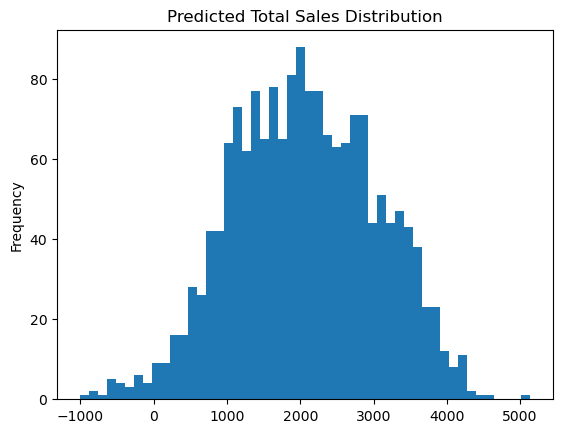

In [37]:
submission_df['total_sales'].plot(kind='hist', bins=50, title='Predicted Total Sales Distribution')

In [38]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor(
    random_state = 50
)

tree_reg = model.fit(X_train, y_train)
y_pred = tree_reg.predict(X_test)

submission_df = pd.DataFrame({
    'id': test_df.index,
    'total_sales': y_pred
})

submission_df.to_csv('submission_v8_1.csv', index=False)

<Axes: title={'center': 'Predicted Total Sales Distribution'}, ylabel='Frequency'>

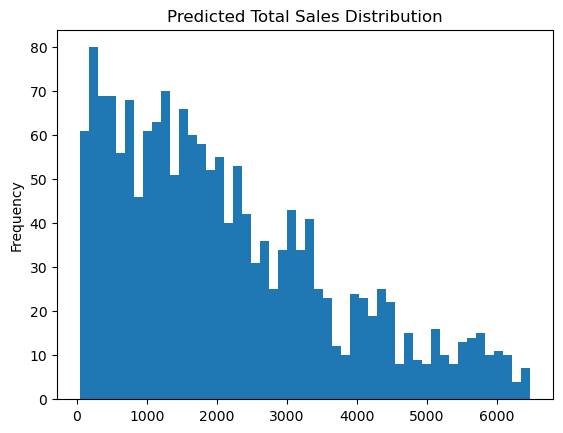

In [39]:
submission_df['total_sales'].plot(kind='hist', bins=50, title='Predicted Total Sales Distribution')

In [40]:
submission_df['total_sales'].describe()

count    1705.000000
mean     2132.820152
std      1566.425894
min        37.000000
25%       878.620000
50%      1764.980000
75%      3070.360000
max      6477.220000
Name: total_sales, dtype: float64

In [ ]:
import category_encoders as ce


# ============================================================
# 1. Separate features and target
# ============================================================

X_train = df_v2.drop(columns=['total_sales', 'fat_content']).copy()
y_train = df_v2['total_sales'].copy()

X_test = test_df_v2.drop(columns=['fat_content']).copy()


# ============================================================
# 3. One-Hot Encoding: store_format
# ============================================================

X_train = pd.get_dummies(
    X_train,
    columns=['store_format'],
    drop_first=True,
    dtype=int
)

X_test = pd.get_dummies(
    X_test,
    columns=['store_format'],
    drop_first=True,
    dtype=int
)

# Make test columns exactly match training columns
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)


# ============================================================
# 4. Target Encoding: product_category
# ============================================================

target_encoder = ce.TargetEncoder(
    cols=['product_category', 'store_code'],
    smoothing=10
)

X_train = target_encoder.fit_transform(
    X_train,
    y_train
)

X_test = target_encoder.transform(
    X_test
)


# ============================================================
# 5. Binary Encoding: product_code
# ============================================================

binary_encoder = ce.BinaryEncoder(
    cols=['product_code', 'store_info'],
    drop_invariant=True
)

X_train = binary_encoder.fit_transform(X_train)

X_test = binary_encoder.transform(X_test)


# ============================================================
# 6. Final alignment check
# ============================================================

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("\nColumns match:", X_train.columns.equals(X_test.columns))

X_train shape: (6674, 25)
X_test shape: (1705, 25)
y_train shape: (6674,)

Columns match: True
